
<div dir=ltr align=center>

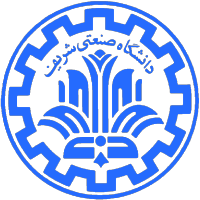

<br>
<font>
<div dir=ltr align=center>
<div dir=ltr align=center>
<font color=0F5298 size=7>
    Artificial Intelligence <br>
<font color=2565AE size=5>
    Computer Engineering Department <br>
    Arash Marioriyad<br>
    Spring 2026<br>
<font color=3C99D size=5>
    Practical HomeWork 4<br>
    Westeros<br>
<font color=696880 size=4>
    Soroush Davaran

____

Name: محمد مهدی مرادی

SID: 403106681

# <center><font color='#B8860B' size='6'>🏰 The Citadel's Secret Records: A Westeros Classification Task 🏰</font></center>

---

<div style='background-color: #1a1a2e; padding: 20px; border-radius: 10px; border-left: 5px solid #e94560;'>

### 📜 <font color='#e94560'>The Grand Maester's Decree</font>

> *"The realm bleeds. Ancient records have been recovered from the ashes of the Great Sept, but many pages are smudged, names lost to time. We possess fragments — hair color, homeland, companions, values, weapons — but the <b>Houses</b> these individuals belong to remain hidden."*
>
> — Grand Maester Samwell Tarly, 305 AC

</div>

---

### 🎭 <font color='#4a90d9'>Your Role, Master of Whisperers</font>

You have been summoned to the **Red Keep** by royal decree. The Crown needs you to:

| Task | Description |
|------|-------------|
| 🔍 <font color='#f39c12'>Investigate</font> | Recovered fragments of 2,000 individuals |
| 🧠 <font color='#9b59b6'>Classify</font> | Determine their allegiance: <b>Stark</b>, <b>Lannister</b>, <b>Targaryen</b>, or <b>Baratheon</b> |
| ⚔️ <font color='#e74c3c'>Build Models</font> | Use <b>Decision Trees</b> and <b>Random Forests</b> to predict House loyalty |
| 📊 <font color='#2ecc71'>Report</font> | Present your findings to the Small Council |

---

<div style='background-color: #16213e; padding: 15px; border-radius: 8px;'>

### 🗡️ <font color='#e94560'>Learning Objectives</font>

- ✅ Understand how **Decision Trees** make splits using Gini Impurity & Information Gain
- ✅ Learn how **Random Forests** combine multiple trees to reduce overfitting
- ✅ Practice preprocessing categorical data for ML pipelines
- ✅ Evaluate classification models using Confusion Matrices & Reports
- ✅ Implement the models yourself for better understanding of the underlying algorithms

</div>

---

<center><font color='#B8860B' size='4'>⚔️ <i>"When you play the game of thrones, you win or you die. There is no middle ground."</i> ⚔️</font></center>
<center><font color='#888' size='2'>— Cersei Lannister</font></center>


In [36]:
# ============================================================
# 📦 Cell 2: Importing the Maester's Tools
# ============================================================
# "A maester is only as good as his instruments."
# ============================================================

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn modules
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Set visual style for the realm
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("✅ All maester tools have been forged and are ready for use.")

✅ All maester tools have been forged and are ready for use.


# <font color='#f39c12'>📚 Cell 3: The Archivist's Duty — Loading the CSV</font>

---

<div style='background-color: #1a1a2e; padding: 20px; border-radius: 10px; border-left: 5px solid #f39c12;'>

> *"The records sit in the vault, sealed in parchment. Only the Archivist can break the seal and bring them into the light."*
>
> — Archivist Ebrose, Oldtown

</div>

---

### 🗃️ <font color='#f39c12'>Your Task, Archivist</font>

The Grand Maester has stored the recovered records in a **CSV file** named `westeros_records.csv`. Before any analysis can begin, you must:

1. **Load** the CSV file into a pandas DataFrame
2. **Inspect** the first few rows to verify the data loaded correctly
3. **Check** the shape and data types of the loaded records

---

<div style='background-color: #16213e; padding: 15px; border-radius: 8px; border: 2px dashed #f39c12;'>

### 📝 <font color='#f39c12'>Student Instructions</font>

> Use `pd.read_csv('westeros_records.csv')` to load the data. Display the first 5 rows and print the DataFrame shape.

</div>


In [37]:
# ============================================================
# 📚 Cell 3: The Archivist Opens the Vault — Load the CSV
# ============================================================
# "Break the seal. Let the records breathe."
# ============================================================

df = pd.read_csv('westeros_records.csv')

display(df.head())

print(f"\n📊 Dataset shape: {df.shape}")

df.info()

,Hair_Color,Region_Climate,Companion_Pet,Core_Value,Weapon,House
0,Red,Hot,Cat,Wealth,Sword,Lannister
1,Auburn,Cold,Dragon,Honor,Valyrian Steel,Stark
2,Black,Temperate,Stag,Power,Dagger,Baratheon
3,Blonde,Temperate,Lion,Wealth,Axe,Lannister
4,Brown,Temperate,Cat,Power,Sword,Lannister



📊 Dataset shape: (2000, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Hair_Color      2000 non-null   object
 1   Region_Climate  2000 non-null   object
 2   Companion_Pet   1629 non-null   object
 3   Core_Value      2000 non-null   object
 4   Weapon          2000 non-null   object
 5   House           2000 non-null   object
dtypes: object(6)
memory usage: 93.9+ KB


# <font color='#e94560'>🔍 Cell 4: Deciphering Smudged Ink — Preprocessing Theory</font>

---

<div style='background-color: #0f3460; padding: 20px; border-radius: 10px; border-left: 5px solid #e94560;'>

> *"The ink runs where the parchment is torn. Words blur together. We must separate each letter, each symbol, before the truth can be read."*
>
> — Maester Wolkan, Winterfell

</div>

---

### 🤖 <font color='#3498db'>Why Do Machines Need Numbers?</font>

Machine learning models are **mathematical engines**. They cannot directly understand:

- `"Direwolf"` vs `"Dragon"` 🐺🐉
- `"Honor"` vs `"Wealth"` ⚔️💰

We must **translate** categorical words into numbers.

---

### 📐 <font color='#f39c12'>Encoding Strategies</font>

| Method | How It Works | Best For |
|--------|-------------|----------|
| **Label Encoding** | Assigns each category a unique integer | Ordinal data |
| **One-Hot Encoding** | Creates binary columns for each category | Nominal data |

---

<div style='background-color: #1a1a2e; padding: 15px; border-radius: 8px; border: 2px dashed #e94560;'>

### 🧠 <font color='#e94560'>Theory Question</font>

> **❓ Why might One-Hot Encoding be safer than Label Encoding for categorical variables like `Weapon`?**
>
> *Hint: If `Sword=0`, `Bow=1`, `Axe=2`, does the model think an Axe is "twice as much" as a Bow?*

دلیل این امر این است که متغیرهایی مانند سلاح هیچ ترتیب یا ارزش عددی ذاتی نسبت به هم ندارند. اگر از Label Encoding استفاده کنیم، مدل به اشتباه تصور می‌کند که بین اعداد رابطه ترتیبی یا ریاضی وجود دارد که این امر مدل را گمراه می‌کند. اما One-Hot Encoding این مشکل را با ایجاد ستون‌های صفر و یک کاملاً مجزا حل می‌کند و از فرضیات غلط ریاضی جلوگیری می‌کند.
</div>


In [38]:
# ============================================================
# 🧹 Cell 5: Preprocessing — Prepare the Records
# ============================================================
# "Clean the parchment. Separate the wheat from the chaff."
# ============================================================

# Step 1: Handle Missing Values (Repair Torn Parchment)
# Replace NaN/missing values in Companion_Pet with "No Pet"
df['Companion_Pet'] = df['Companion_Pet'].fillna('No Pet')

# Step 2: Separate features (X) from target (y)
X = df.drop('House', axis=1)
y = df['House']

# Step 3: Encode the target variable into numerical labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Step 4: One-Hot Encode categorical features in X
X_encoded = pd.get_dummies(X, drop_first=True)

# Step 5: Split into training (80%) and testing (20%) sets
# CRITICAL: By Royal Decree, we use exactly test_size=0.2 and random_state=42
# This ensures the Small Council evaluates exactly 400 records (20% of 2000).
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} records (80%)")
print(f"Testing set size: {X_test.shape[0]} records (20%)")
print(f"Number of features after encoding: {X_train.shape[1]}")
print(f"Encoded classes: {le.classes_}")

Training set size: 1600 records (80%)
Testing set size: 400 records (20%)
Number of features after encoding: 27
Encoded classes: ['Baratheon' 'Lannister' 'Stark' 'Targaryen']


# <font color='#2ecc71'>🌳 Cell 6: Ned Stark's Logic — Decision Tree Theory</font>

---

<div style='background-color: #1a472a; padding: 20px; border-radius: 10px; border-left: 5px solid #2ecc71;'>

> *"I remember when I first saw Robert's children. Joffrey, Myrcella, Tommen — all golden-haired. Not a single Baratheon black hair among them. The seed is strong, my lord, but not in this case."*
>
> — Ned Stark

</div>

---

Ned performed **feature-based splitting**:

```
Is Hair Color = Black (Baratheon)?
├── YES → Likely a true Baratheon child
└── NO  → Is Hair Color = Blonde?
    ├── YES → Likely a Lannister child
    └── NO  → Further investigation needed
```

---

### 📐 <font color='#f39c12'>The Mathematics of Splitting</font>

#### 🎯 Gini Impurity

$$Gini = 1 - \sum_{i=1}^{C} p_i^2$$

Where $p_i$ is the probability of class $i$ in the node.

- **Gini = 0** → Pure node ✅
- **Gini = 0.75** → Maximum impurity for 4 classes ❌

#### 📈 Information Gain

$$IG = Gini_{parent} - \sum_{j} \frac{N_j}{N} \cdot Gini_{child_j}$$

The tree picks the feature that **maximizes Information Gain**.

---

<div style='background-color: #1a1a2e; padding: 15px; border-radius: 8px; border: 2px dashed #2ecc71;'>

### 🧠 <font color='#2ecc71'>Theory Question</font>

> **❓ If a node contains 100 Starks and 0 Lannisters, what is the Gini Impurity?**

گره کاملاً خالص است.
مقدار Gini برابر با 0 است.

1 - (1^2 + 0^2) = 0

> **❓ If a node contains 50 Starks and 50 Lannisters, what is the Gini Impurity?**

مقدار Gini برابر با 0.5 است.

1 - (0.5^2 + 0.5^2) = 0.5
</div>


🌳 Decision Tree Accuracy: 0.7900


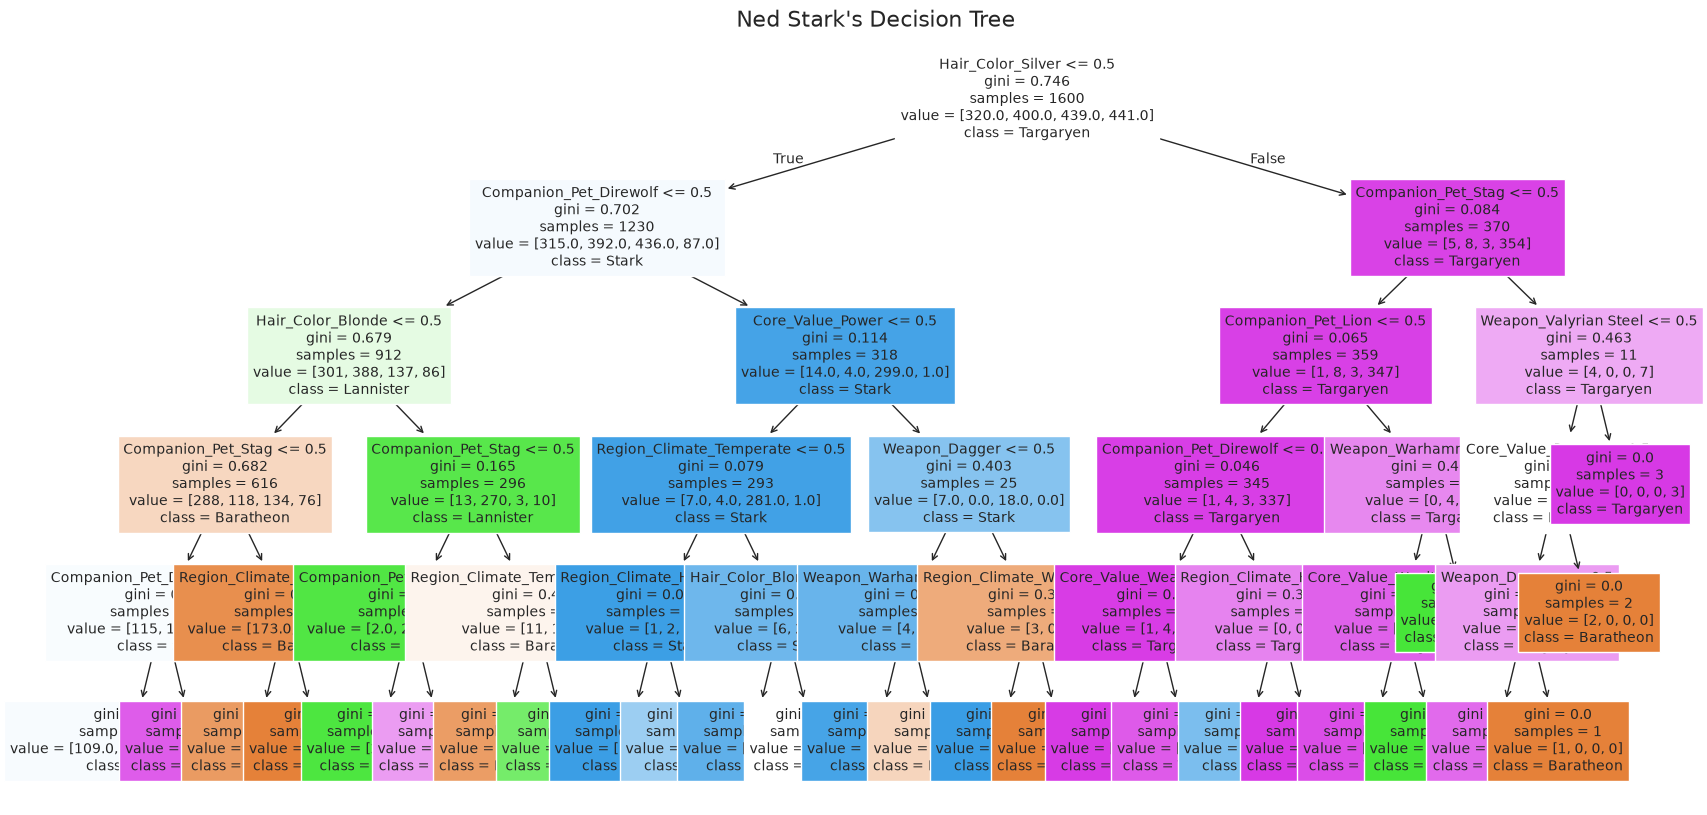


🔑 Root Node Feature (Most Important Split): Hair_Color_Silver


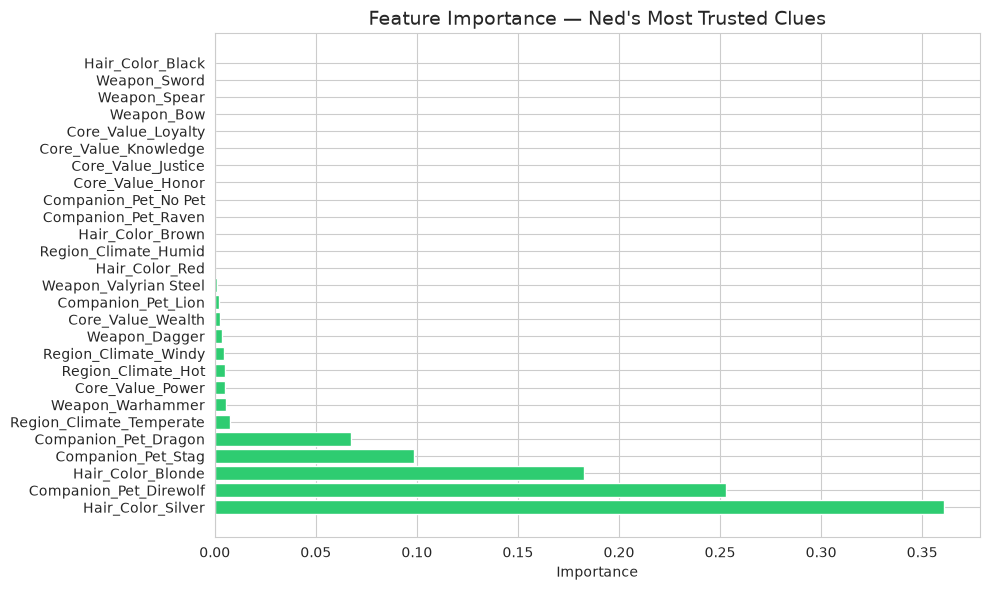

In [39]:
# ============================================================
# 🌳 Cell 7: Building Ned Stark's Decision Tree
# ============================================================
# "The lone wolf dies, but the tree of decisions stands."
# ============================================================

# Step 1: Initialize a DecisionTreeClassifier
dt_classifier = DecisionTreeClassifier(random_state=42, max_depth=5)

# Step 2: Train (fit) the Decision Tree on training data
dt_classifier.fit(X_train, y_train)

# Step 3: Make predictions on the test data
y_pred_dt = dt_classifier.predict(X_test)

# Step 4: Calculate and print the accuracy
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"🌳 Decision Tree Accuracy: {accuracy_dt:.4f}")

# Step 5: VISUALIZE THE FULL DECISION TREE
plt.figure(figsize=(20, 10))
plot_tree(
    dt_classifier,
    filled=True,
    feature_names=X_train.columns,
    class_names=le.classes_,
    fontsize=10
)
plt.title("Ned Stark's Decision Tree", fontsize=16)
plt.show()

# Step 6: Extract and print the ROOT NODE FEATURE
root_feature_name = X_train.columns[dt_classifier.tree_.feature[0]]
print(f"\n🔑 Root Node Feature (Most Important Split): {root_feature_name}")

# Step 7: Plot Feature Importance as a horizontal bar chart
importances = dt_classifier.feature_importances_
indices = np.argsort(importances)
plt.figure(figsize=(10, 6))
plt.title("Feature Importance — Ned's Most Trusted Clues", fontsize=14)
plt.barh(range(X_train.shape[1]), importances[indices], color='#2ecc71')
plt.yticks(range(X_train.shape[1]), [X_train.columns[i] for i in indices])
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# <font color='#9b59b6'>🌲 Cell 8: The Small Council — Random Forest Theory</font>

---

<div style='background-color: #2c1654; padding: 20px; border-radius: 10px; border-left: 5px solid #9b59b6;'>

> *"A single lord may be blind to his own biases. But a council of a hundred lords, each seeing different pieces of the truth, will arrive at wisdom."*
>
> — Tyrion Lannister

</div>

---

### ⚖️ <font color='#9b59b6'>The Problem with One Lord (One Tree)</font>

| Problem | GoT Analogy | ML Term |
|---------|-------------|--------|
| Memorizes training data | A lord who only knows his own castle | **Overfitting** |
| Fails on new data | Useless against new enemy tactics | **Poor Generalization** |

---

### 👑 <font color='#f39c12'>The Small Council Solution (Random Forest)</font>

#### 🎲 Bootstrap Aggregation (Bagging)
Each tree trains on a **random sample with replacement**.

#### 🔀 Feature Randomness
At each split, a tree considers only a **random subset of features**.

#### 🗳️ Majority Voting
All trees vote; the majority wins.

---

<div style='background-color: #1a1a2e; padding: 15px; border-radius: 8px; border: 2px dashed #9b59b6;'>

### 🧠 <font color='#9b59b6'>Theory Question</font>

> **❓ How does the `max_depth` hyperparameter prevent a Lord from jumping to wild conclusions (overfitting)?**
>
> *Hint: What happens when a tree grows infinitely deep vs. when `max_depth=3`?*

 محدود کردن عمق درخت باعث میشود که درخت ما نتواند تمامی جزئیات ریز و نویز های داده تست را حفظ کند و این باعث میشود که احتمال overfitting کم شود .

</div>


🌲 Random Forest Accuracy: 0.8925

📊 Model Comparison:
   Decision Tree Accuracy:  0.7900
   Random Forest Accuracy:  0.8925
   Improvement: 10.25%


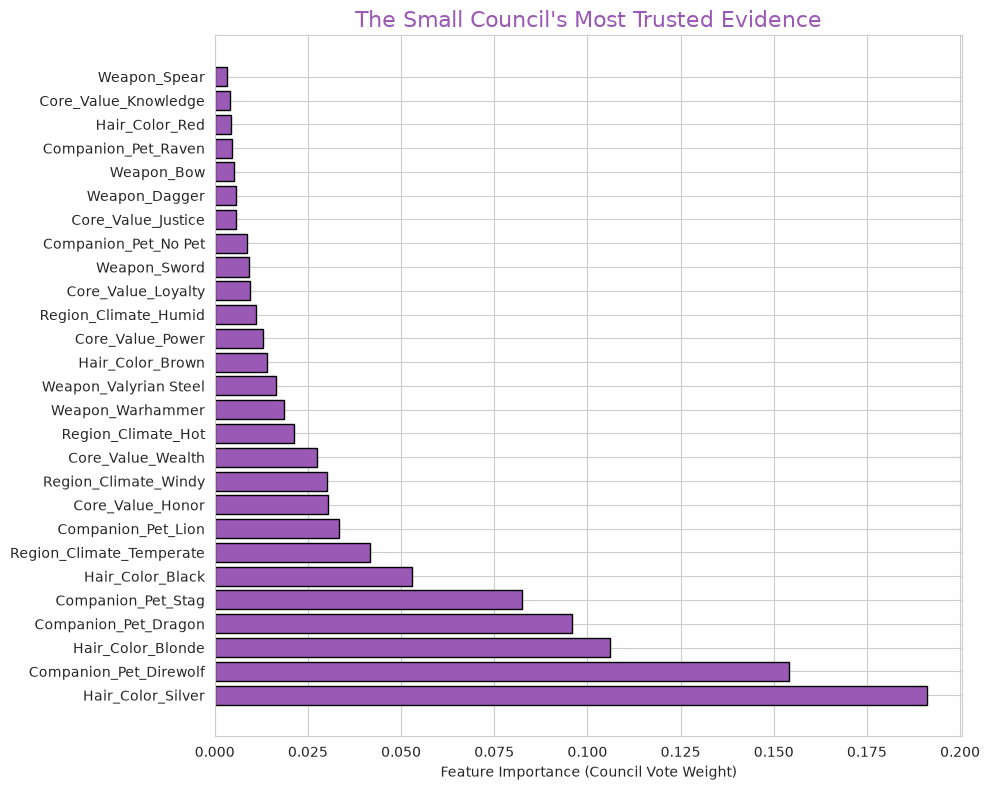


🏆 Top 3 Most Important Features (Random Forest):
   1. Hair_Color_Silver: 0.1911
   2. Companion_Pet_Direwolf: 0.1542
   3. Hair_Color_Blonde: 0.1060


In [40]:
# ============================================================
# 🌲 Cell 9: Assembling the Small Council (Random Forest)
# ============================================================
# "A hundred lords, a hundred perspectives, one wise decision."
# ============================================================

# Step 1: Initialize a RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

# Step 2: Train (fit) the Random Forest on training data
rf_model.fit(X_train, y_train)

# Step 3: Make predictions on the test data
y_pred_rf = rf_model.predict(X_test)

# Step 4: Calculate and print the accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"🌲 Random Forest Accuracy: {accuracy_rf:.4f}")

# Step 5: Compare with Decision Tree
print(f"\n📊 Model Comparison:")
print(f"   Decision Tree Accuracy:  {accuracy_dt:.4f}")
print(f"   Random Forest Accuracy:  {accuracy_rf:.4f}")
print(f"   Improvement: {(accuracy_rf - accuracy_dt)*100:.2f}%")

# Step 6: Plot Feature Importances (horizontal bar chart)
importances_rf = rf_model.feature_importances_
indices_rf = np.argsort(importances_rf)
plt.figure(figsize=(10, 8))
plt.title("The Small Council's Most Trusted Evidence", fontsize=16, color='#9b59b6')
plt.barh(range(X_train.shape[1]), importances_rf[indices_rf], color='#9b59b6', edgecolor='black')
plt.yticks(range(X_train.shape[1]), [X_train.columns[i] for i in indices_rf])
plt.xlabel("Feature Importance (Council Vote Weight)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Step 7: Print the TOP 3 MOST IMPORTANT FEATURES
top3_indices = indices_rf[-3:][::-1]
print("\n🏆 Top 3 Most Important Features (Random Forest):")
for rank, idx in enumerate(top3_indices, 1):
    print(f"   {rank}. {X_train.columns[idx]}: {importances_rf[idx]:.4f}")

# <font color='#e74c3c'>📊 Cell 10: Reporting to the King — Evaluation</font>

---

<div style='background-color: #4a0e0e; padding: 20px; border-radius: 10px; border-left: 5px solid #e74c3c;'>

> *"Accuracy is not enough, Master of Whisperers. I need to know WHERE your spies fail."*
>
> — King Bran the Broken

</div>

---

### 📋 <font color='#f39c12'>Confusion Matrix & Classification Report</font>

| Metric | Formula | Meaning |
|--------|---------|--------|
| **Precision** | $\frac{TP}{TP + FP}$ | Of all predicted as House X, how many actually are? |
| **Recall** | $\frac{TP}{TP + FN}$ | Of all actually House X, how many did we find? |
| **F1-Score** | $2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$ | Harmonic mean of both |

---

<center><font color='#B8860B'>📊 <i>"The numbers, Your Grace. They tell the truth when men lie."</i></font></center>



📋 Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.55      0.64        77
           1       0.97      0.71      0.82       107
           2       0.64      0.90      0.74       117
           3       0.90      0.94      0.92        99

    accuracy                           0.79       400
   macro avg       0.82      0.77      0.78       400
weighted avg       0.82      0.79      0.79       400


📋 Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81        77
           1       0.90      0.91      0.90       107
           2       0.93      0.86      0.89       117
           3       0.94      0.95      0.94        99

    accuracy                           0.89       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.89      0.89      0.89       400



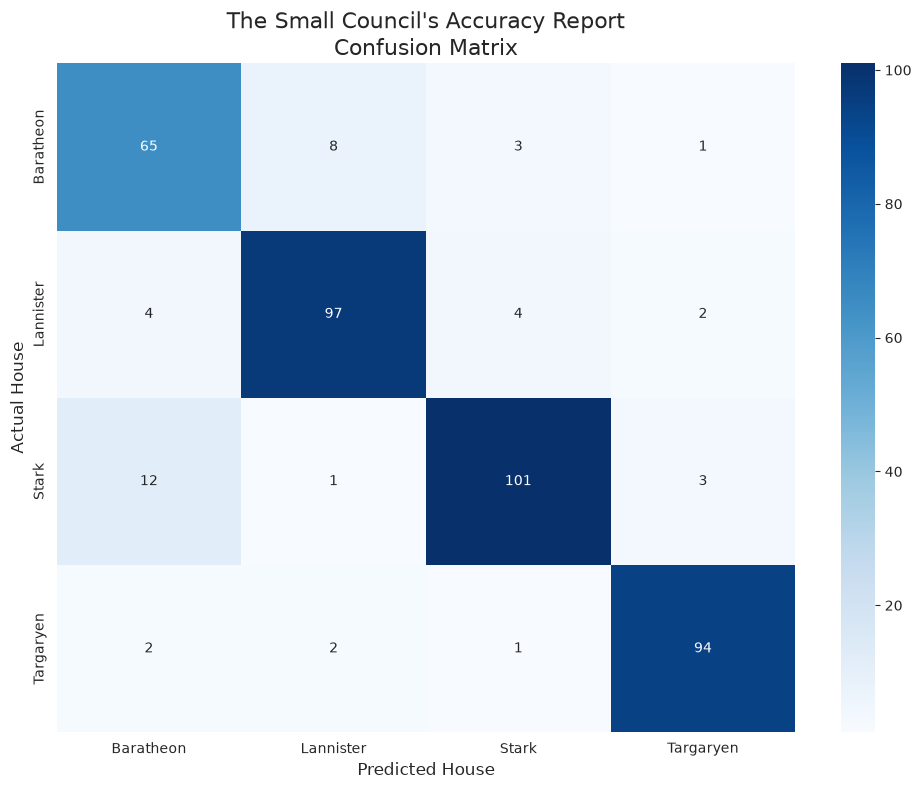


🏰 THE CITADEL'S FINAL REPORT
🌳 Decision Tree Accuracy:  79.00%
🌲 Random Forest Accuracy:  89.25%

👑 The Small Council outperformed the lone lord by 10.25%

⚔️ 'Winter is coming, but our models are ready.'


In [41]:
# ============================================================
# 📊 Cell 11: The Final Report — Evaluation & Confusion Matrix
# ============================================================
# "Present your findings to the King. Leave no stone unturned."
# ============================================================

# Step 1: Print the Classification Report for the Decision Tree
print("\n📋 Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))

# Step 2: Print the Classification Report for the Random Forest
print("\n📋 Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Step 3: Compute and plot the Confusion Matrix (Seaborn heatmap)
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("The Small Council's Accuracy Report\nConfusion Matrix", fontsize=16)
plt.ylabel("Actual House", fontsize=12)
plt.xlabel("Predicted House", fontsize=12)
plt.tight_layout()
plt.show()

# Final Summary
print("\n" + "="*60)
print("🏰 THE CITADEL'S FINAL REPORT")
print("="*60)
print(f"🌳 Decision Tree Accuracy:  {accuracy_dt:.2%}")
print(f"🌲 Random Forest Accuracy:  {accuracy_rf:.2%}")
print(f"\n👑 The Small Council outperformed the lone lord by {(accuracy_rf - accuracy_dt)*100:.2f}%")
print("\n⚔️ 'Winter is coming, but our models are ready.'")
print("="*60)

# <font color='#2ecc71'>🔨 Cell 11: Forging Ned's Steel — Decision Tree From Scratch</font>

---

<div style='background-color: #1a472a; padding: 20px; border-radius: 10px; border-left: 5px solid #2ecc71;'>

> *"Anyone can pick up a blade handed to them by the armorer. A true swordsman knows every fold in the steel — why it bends, why it holds, how it was forged. That is what separates a master from a student."*
>
> — Syrio Forel, First Sword of Braavos

</div>

---

The Citadel handed you `DecisionTreeClassifier` — a fine blade, masterfully crafted by the smiths at sklearn. But the Grand Maester is not satisfied with students who merely wield borrowed steel.

**To earn the Maester's Chain, you must now forge the blade yourself.** Implement `DecisionTreeScratch` from nothing but `numpy`.

---

### 🗺️ <font color='#f39c12'>The Blacksmith's Blueprint</font>

The tree is built by **recursive splitting**: at each node, find the single question whose answer best separates the Houses, then split and repeat on each half.

```
fit(X, y):
    _build_tree(X, y, depth=0)
        → _best_split: for every (feature, threshold), measure Information Gain
        → pick the pair with the highest gain
        → left  = samples where feature ≤ threshold
        → right = samples where feature  > threshold
        → recurse on left  (_build_tree, depth+1)
        → recurse on right (_build_tree, depth+1)
        → STOP when: node is pure / depth = max_depth / too few samples
        → leaf stores the majority class of y
```

---

### 📐 <font color='#f39c12'>The Mathematics of the Forge</font>

#### 🎯 Gini Impurity — how mixed is the blood in a node?

$$Gini(S) = 1 - \sum_{k=1}^{C} p_k^2$$

- **Gini = 0** → pure node (all one House) ✅
- **Gini = 0.75** → maximum chaos, four Houses equally split ❌

#### 📈 Information Gain — the reward for a split into $S_L$ and $S_R$:

$$IG = Gini(S) - \frac{|S_L|}{|S|} \cdot Gini(S_L) - \frac{|S_R|}{|S|} \cdot Gini(S_R)$$

The tree picks the **(feature, threshold)** pair that **maximises** $IG$.

---

### ⚙️ <font color='#2ecc71'>Key Hyperparameters</font>

| Parameter | Description |
|-----------|-------------|
| `max_depth` | Caps the blade's length — deeper trees memorise, shallow trees generalise |
| `min_samples_split` | A node with fewer samples becomes a leaf immediately |
| `criterion` | `'gini'` (fast) or `'entropy'` (Information Gain formulation) |

---

<div style='background-color: #1a1a2e; padding: 15px; border-radius: 8px; border: 2px dashed #2ecc71;'>

### 🧠 <font color='#2ecc71'>Blacksmith's Tip</font>

> Use a lightweight **`Node`** class with five fields: `feature` (index), `threshold`, `left`, `right`, and `value` (majority class). A node is a **leaf** when `value is not None`, and an **internal node** otherwise.

</div>

In [42]:
# ============================================================
# 🌳 DecisionTreeScratch — Custom Implementation
# ============================================================

from collections import Counter
import numpy as np

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    def is_leaf(self):
        return self.value is not None


class DecisionTreeScratch:
    def __init__(self, max_depth=5, min_samples_split=2, criterion='gini'):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.criterion = criterion
        self.root = None

    def fit(self, X, y):
        X_arr = np.array(X) if not isinstance(X, np.ndarray) else X
        y_arr = np.array(y) if not isinstance(y, np.ndarray) else y
        self.root = self._build_tree(X_arr, y_arr, depth=0)

    def predict(self, X):
        X_arr = np.array(X) if not isinstance(X, np.ndarray) else X
        return np.array([self._traverse_tree(x, self.root) for x in X_arr])

    # ---- impurity helpers ------------------------------------------------

    def _gini(self, y):
        proportions = np.array(list(Counter(y).values())) / len(y)
        return 1.0 - np.sum(proportions ** 2)

    def _entropy(self, y):
        proportions = np.array(list(Counter(y).values())) / len(y)
        return -np.sum(proportions * np.log2(proportions + 1e-9))

    def _impurity(self, y):
        if self.criterion == 'entropy':
            return self._entropy(y)
        return self._gini(y)

    # ---- split search ----------------------------------------------------

    def _information_gain(self, y, col, threshold):
        parent_impurity = self._impurity(y)
        left_mask = col <= threshold
        right_mask = col > threshold
        y_left, y_right = y[left_mask], y[right_mask]
        
        if len(y_left) == 0 or len(y_right) == 0:
            return 0.0
            
        n = len(y)
        child_impurity = (len(y_left) / n) * self._impurity(y_left) + (len(y_right) / n) * self._impurity(y_right)
        gain = parent_impurity - child_impurity
        return gain

    def _best_split(self, X, y):
        best_gain = -1.0
        best_feature = None
        best_threshold = None
        
        for feat_idx in range(X.shape[1]):
            col = X[:, feat_idx]
            thresholds = np.unique(col)
            for threshold in thresholds:
                gain = self._information_gain(y, col, threshold)
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feat_idx
                    best_threshold = threshold
                    
        return best_feature, best_threshold

    # ---- tree building ---------------------------------------------------

    def _build_tree(self, X, y, depth):
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))
        
        if depth >= self.max_depth or n_labels == 1 or n_samples < self.min_samples_split:
            leaf_value = Counter(y).most_common(1)[0][0]
            return Node(value=leaf_value)
            
        best_feature, best_threshold = self._best_split(X, y)
        
        if best_feature is None:
            leaf_value = Counter(y).most_common(1)[0][0]
            return Node(value=leaf_value)
            
        left_mask = X[:, best_feature] <= best_threshold
        right_mask = X[:, best_feature] > best_threshold
        
        left = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right = self._build_tree(X[right_mask], y[right_mask], depth + 1)
        
        return Node(feature=best_feature, threshold=best_threshold, left=left, right=right)

    def _traverse_tree(self, x, node):
        if node.is_leaf():
            return node.value
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)


# Quick sanity check (runs after preprocessing cell has been executed)
dt_scratch = DecisionTreeScratch(max_depth=5, criterion='gini')
dt_scratch.fit(X_train, y_train)
y_pred_dt_scratch = dt_scratch.predict(X_test)
accuracy_dt_scratch = accuracy_score(y_test, y_pred_dt_scratch)
print(f"🌳 DecisionTreeScratch Accuracy:       {accuracy_dt_scratch:.4f}")
print(f"   sklearn DecisionTreeClassifier:    {accuracy_dt:.4f}")

🌳 DecisionTreeScratch Accuracy:       0.7950
   sklearn DecisionTreeClassifier:    0.7900


# <font color='#9b59b6'>⚒️ Cell 12: Assembling Your Own Council — Random Forest From Scratch</font>

---

<div style='background-color: #2c1654; padding: 20px; border-radius: 10px; border-left: 5px solid #9b59b6;'>

> *"They told me it was impossible — Free Folk, Night's Watch, knights of the Vale, all fighting as one. I didn't wait for the gods to hand me an army. I forged every alliance myself, one by one."*
>
> — Jon Snow, King in the North

</div>

---

You have summoned the Small Council and watched it outperform the lone lord. But `RandomForestClassifier` was **handed to you** — a council assembled by another hand.

**Now forge your own.** Implement `RandomForestScratch` by building each tree from scratch and binding them with the two ancient spells that make a forest wise: **Bootstrap Bagging** and **Feature Randomness**.

---

### 🛡️ <font color='#f39c12'>The Two Ancient Spells That Forge a Council</font>

#### 🎲 Spell I — Bootstrap Bagging
For each tree, draw **N samples with replacement** from the training set. Every lord sees a slightly different version of the realm — on average ~63% of unique records, the rest repeated. This decorrelates the lords from one another.

#### 🔀 Spell II — Feature Randomness
At every split, each lord may only consult a **random subset of $\sqrt{p}$ features** instead of all evidence. This prevents the most powerful feature from dominating every lord's judgment, decorrelating the council further.

#### 🗳️ Final Decree — Majority Vote
All lords cast their vote. The House with the most votes wins.

---

### ⚖️ <font color='#9b59b6'>Why the Forged Council Outperforms the Borrowed One</font>

| Source of Randomness | Effect on the Council |
|----------------------|-----------------------|
| Bootstrap sampling | Each lord sees different records → lords disagree constructively |
| Feature subsampling | No single clue dominates every vote → further decorrelation |

The variance of the council's averaged judgment: $\rho\,\sigma^2 + \frac{1-\rho}{B}\sigma^2$. Reducing lord-to-lord correlation $\rho$ is just as powerful as adding more lords $B$.

---

### ⚙️ <font color='#9b59b6'>Key Hyperparameters</font>

| Parameter | Description |
|-----------|-------------|
| `n_estimators` | Number of lords — more lords, lower variance (diminishing returns) |
| `max_depth` | Each lord's tree depth — prevents individual lords from overfitting |
| `max_features` | Clues per split: `'sqrt'` → $\sqrt{p}$ features considered |
| `min_samples_split` | Minimum records for a lord to bother splitting further |

---

<div style='background-color: #1a1a2e; padding: 15px; border-radius: 8px; border: 2px dashed #9b59b6;'>

### 🧠 <font color='#9b59b6'>Council Architect's Tip</font>

> Subclass `DecisionTreeScratch` and override `_best_split` to first randomly draw `max_features` feature indices before searching for the best split. `RandomForestScratch.fit` then loops `n_estimators` times: draw a bootstrap sample, train one such subclassed tree, append it to the council.

</div>

In [43]:
# ============================================================
# 🌳 DecisionTreeScratch — Custom Implementation
# ============================================================

import numpy as np
from collections import Counter
class _RandomTreeScratch(DecisionTreeScratch):

    def __init__(self, max_depth, min_samples_split, max_features, rng):
        super().__init__(max_depth=max_depth, min_samples_split=min_samples_split)
        self.max_features = max_features
        self._rng = rng

    def _best_split(self, X, y):
        n_samples, n_features = X.shape
        
        if self.max_features == 'sqrt':
            n_sub_features = int(np.sqrt(n_features))
        elif self.max_features == 'log2':
            n_sub_features = int(np.log2(n_features))
        elif isinstance(self.max_features, int):
            n_sub_features = self.max_features
        else:
            n_sub_features = n_features
            
        n_sub_features = max(1, min(n_sub_features, n_features))
        feature_indices = self._rng.choice(n_features, n_sub_features, replace=False)
        
        best_gain = 0.0
        best_feature = None
        best_threshold = None
        
        for feat_idx in feature_indices:
            col = X[:, feat_idx]
            thresholds = np.unique(col)
            for threshold in thresholds:
                gain = self._information_gain(y, col, threshold)
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feat_idx
                    best_threshold = threshold
                    
        return best_feature, best_threshold


class RandomForestScratch:
    def __init__(self, n_estimators=100, max_depth=10, min_samples_split=2,
                 max_features='sqrt', random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.random_state = random_state
        self.trees = []

    def fit(self, X, y):
        X_arr = np.array(X) if not isinstance(X, np.ndarray) else X
        y_arr = np.array(y) if not isinstance(y, np.ndarray) else y
        
        rng = np.random.RandomState(self.random_state)
        self.trees = []
        
        for _ in range(self.n_estimators):
            X_sample, y_sample = self._bootstrap_sample(X_arr, y_arr, rng)
            tree = _RandomTreeScratch(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                max_features=self.max_features,
                rng=rng
            )
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def predict(self, X):
        X_arr = np.array(X) if not isinstance(X, np.ndarray) else X
        
        tree_preds = np.array([tree.predict(X_arr) for tree in self.trees])
        tree_preds = tree_preds.T
        
        final_preds = []
        for sample_preds in tree_preds:
            most_common = Counter(sample_preds).most_common(1)[0][0]
            final_preds.append(most_common)
            
        return np.array(final_preds)

    def _bootstrap_sample(self, X, y, rng):
        n_samples = X.shape[0]
        indices = rng.choice(n_samples, n_samples, replace=True)
        return X[indices], y[indices]


rf_scratch = RandomForestScratch(n_estimators=100, max_depth=10, random_state=42)
rf_scratch.fit(X_train, y_train)
y_pred_rf_scratch = rf_scratch.predict(X_test)
accuracy_rf_scratch = accuracy_score(y_test, y_pred_rf_scratch)
print(f"🌲 RandomForestScratch Accuracy:       {accuracy_rf_scratch:.4f}")
print(f"   sklearn RandomForestClassifier:    {accuracy_rf:.4f}")

🌲 RandomForestScratch Accuracy:       0.8825
   sklearn RandomForestClassifier:    0.8925
